In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import matplotlib as mpl
# mpl.rcParams["font.family"] = "Avenir"

# Poisson-distributed inputs at 5 Hz

- [ ] Does the neuron generate spikes? If so: what is their frequency and does it differ between TI / no TI conditions?
- [ ] TODO: 5 Hz stimulation with 1000 Hz carrier, with varying intensity.

## Example traces in a single cell (add to supplementary?)

In [2]:
cell_ids = np.arange(0, 20)

cell_id = 0
frequency = 5
carrier = 1000
beat = 5
filetype = "voltage.csv"

ti_9_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.9_0.1/{filetype}"
ti_8_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.8_0.1/{filetype}"
ti_7_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.7_0.1/{filetype}"
ti_6_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.6_0.1/{filetype}"
ti_5_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.5_0.1/{filetype}"
noti_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/noTI_0.1/{filetype}"

ti_9 = pd.read_csv(ti_9_filename, index_col=0)
ti_8 = pd.read_csv(ti_8_filename, index_col=0)
ti_7 = pd.read_csv(ti_7_filename, index_col=0)
ti_6 = pd.read_csv(ti_6_filename, index_col=0)
ti_5 = pd.read_csv(ti_5_filename, index_col=0)
noti = pd.read_csv(noti_filename, index_col = 0)

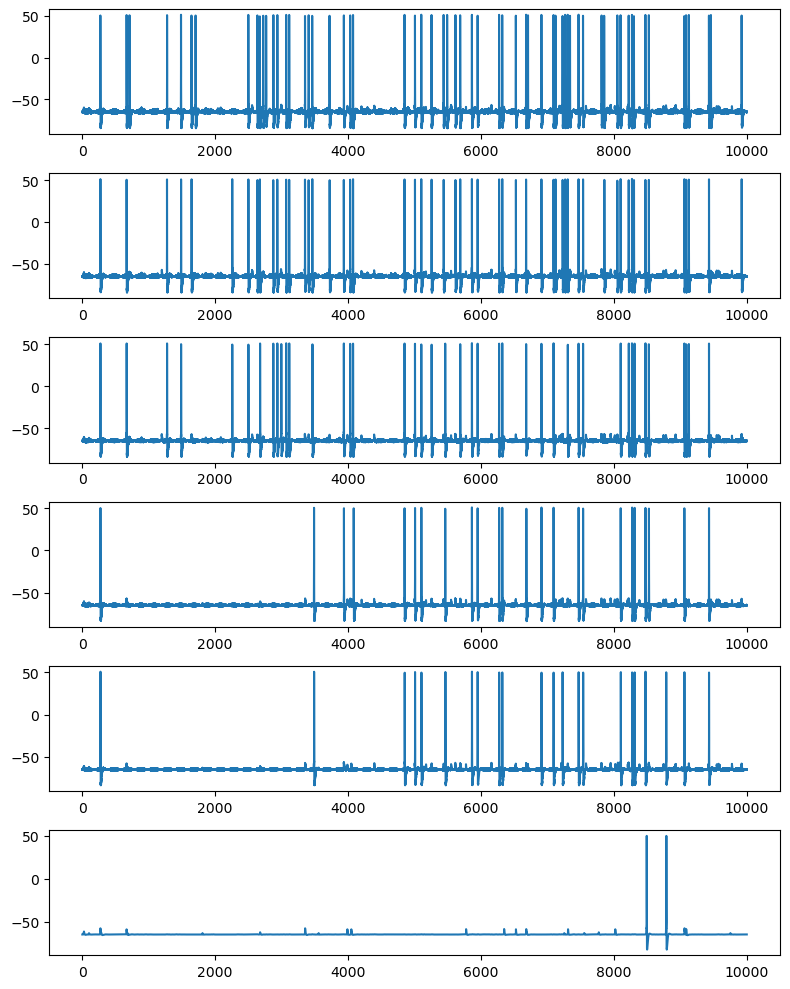

In [3]:
fig, axs = plt.subplots(nrows = 6, ncols = 1, figsize = (8, 10))

axs[0].plot(ti_9.Time, ti_9.Voltage)
axs[1].plot(ti_8.Time, ti_8.Voltage)
axs[2].plot(ti_7.Time, ti_7.Voltage)
axs[3].plot(ti_6.Time, ti_6.Voltage)
axs[4].plot(ti_5.Time, ti_5.Voltage)
axs[5].plot(noti.Time, noti.Voltage)

plt.tight_layout()
plt.show()

In [4]:
filetype = "synapse_weights.csv"

ti_9_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.9_0.1/{filetype}"
ti_8_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.8_0.1/{filetype}"
ti_7_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.7_0.1/{filetype}"
ti_6_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.6_0.1/{filetype}"
ti_5_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{carrier}_{beat}_0.5_0.1/{filetype}"
noti_filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/noTI_0.1/{filetype}"

ti_9 = pd.read_csv(ti_9_filename, index_col=0)
ti_8 = pd.read_csv(ti_8_filename, index_col=0)
ti_7 = pd.read_csv(ti_7_filename, index_col=0)
ti_6 = pd.read_csv(ti_6_filename, index_col=0)
ti_5 = pd.read_csv(ti_5_filename, index_col=0)
noti = pd.read_csv(noti_filename, index_col = 0)

In [5]:
synapse_cols = [f"Synapse{idx}" for idx in range(0, 10)]

ti_9_mean = ti_9[synapse_cols].to_numpy().mean(axis = 1)
ti_8_mean = ti_8[synapse_cols].to_numpy().mean(axis = 1)
ti_7_mean = ti_7[synapse_cols].to_numpy().mean(axis = 1)
ti_6_mean = ti_6[synapse_cols].to_numpy().mean(axis = 1)
ti_5_mean = ti_5[synapse_cols].to_numpy().mean(axis = 1)
noti_mean = noti[synapse_cols].to_numpy().mean(axis = 1)

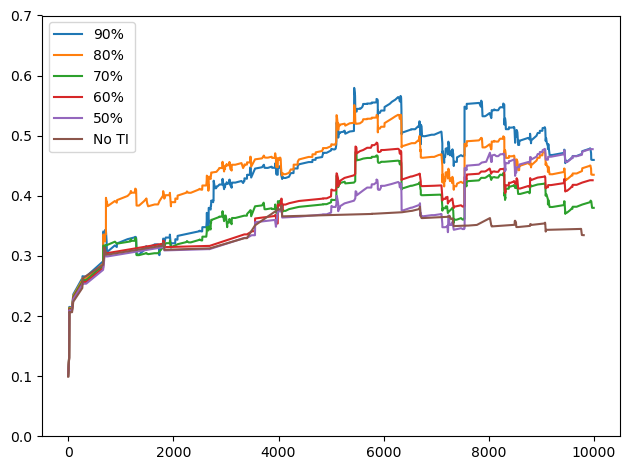

In [6]:
plt.plot(ti_9.Time, ti_9_mean, label = "90%")
plt.plot(ti_8.Time, ti_8_mean, label = "80%")
plt.plot(ti_7.Time, ti_7_mean, label = "70%")
plt.plot(ti_6.Time, ti_6_mean, label = "60%")
plt.plot(ti_5.Time, ti_5_mean, label = "50%")
plt.plot(noti.Time, noti_mean, label = "No TI")
plt.ylim(0, 0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Average across configurations

To show:

- somatic firing frequency in different strengths (**expecting no difference** between no TI / TI conditions, starting at some stimulation strength)
- final weight distribution (**expecting a difference** in weight distribution, starting at some -- ideally the same -- stimulation strength)
- dendritic spiking frequency (**expecting a difference**)

In [7]:
cell_ids = np.arange(0, 20)
frequency = 5
carrier = 1000
beat = 5
amplitudes = [-1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

In [8]:
# Somatic firing frequency

filetype = "spike_frequency.csv"

results = list()
for cell_id in cell_ids:
    for amplitude in amplitudes:
        if amplitude == -1:
            stim = "noTI"
        else:
            if amplitude == 0: stim = f"{carrier}_0_0.32"
            else: stim = f"{carrier}_{beat}_{amplitude}"
        
        filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
        n_spikes = len(pd.read_csv(filename, index_col = 0))
        spike_freq = n_spikes / 10

        if amplitude == -1: label = "No TI"
        else:
            if amplitude == 0: label = f"Pure\ncarrier"
            else: label = f"{round(amplitude * 100)}%"
        
        results.append(
            pd.DataFrame({
                "Amplitude": [label],
                "Frequency": [spike_freq]
            })
        )

results = pd.concat(results)

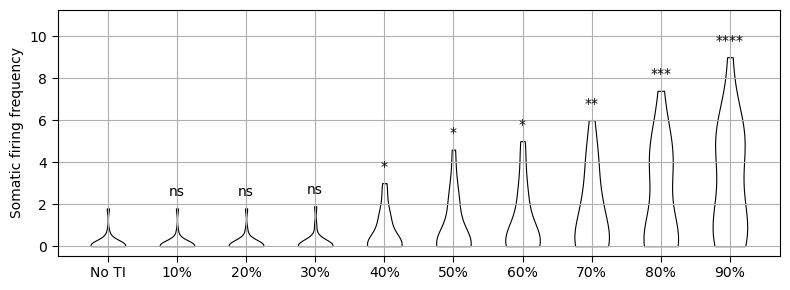

In [9]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

fig, ax = plt.subplots(figsize=(8, 3))

# group data
grouped = list(results.groupby("Amplitude"))
labels = [name for name, _ in grouped]
groups = [g["Frequency"].values for _, g in grouped]

# reorder
priority = ["No TI"]
order = priority + [l for l in labels if l not in priority]

label_to_group = dict(zip(labels, groups))
labels = order
groups = [label_to_group[l] for l in labels]

# violin plot
vp = ax.violinplot(
    groups,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# style violins (black & white)
for body in vp["bodies"]:
    body.set_facecolor("white")
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(1)

# ticks
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

ax.set_ylabel("Somatic firing frequency")
ax.set_xlabel("")

ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.tick_params(axis="x", bottom=True, top=False, length=4)
ax.tick_params(axis="y", left=True, right=False, length=4)

# stats vs "No TI"
ref_idx = labels.index("No TI")

y_max = max([g.max() for g in groups])
y_offset = 0.05 * y_max

for i in range(len(groups)):
    if i == ref_idx:
        continue

    stat, p_val = stats.ttest_ind(groups[ref_idx], groups[i])
    stars = p_to_stars(p_val)

    x = i + 1
    y = groups[i].max() + y_offset

    ax.text(x, y, stars, ha="center", va="bottom")

ax.set_ylim(top=y_max + 5 * y_offset)

for spine in ["bottom", "left"]:
    ax.spines[spine].set_visible(True)

ax.grid(0.25)
plt.tight_layout()
plt.show()

In [10]:
# Final weight distributions (violin plots?)

filetype = "synapse_weights.csv"
synapse_cols = [f"Synapse{idx}" for idx in range(0, 10)]

results = list()
for cell_id in cell_ids:
    for amplitude in amplitudes:
        if amplitude == -1:
            stim = "noTI"
        else:
            if amplitude == 0: continue # stim = f"{carrier}_0_0.32"
            else: stim = f"{carrier}_{beat}_{amplitude}"
        
        filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
        synapse_weights = pd.read_csv(filename, index_col = 0)
        weights = synapse_weights[synapse_cols].iloc[-1].tolist()
        
        if amplitude == -1: label = "No TI"
        else:
            if amplitude == 0: label = f"Pure carrier"
            else: label = f"{round(amplitude * 100)}%"
        
        results.append(
            pd.DataFrame({
                "Amplitude": label,
                "Weights": weights,
                "SynapseID": [ f"{synapse}_{cell_id}" for synapse in synapse_cols ]
            })
        )

results = pd.concat(results)
print(carrier)
print(beat)

1000
5


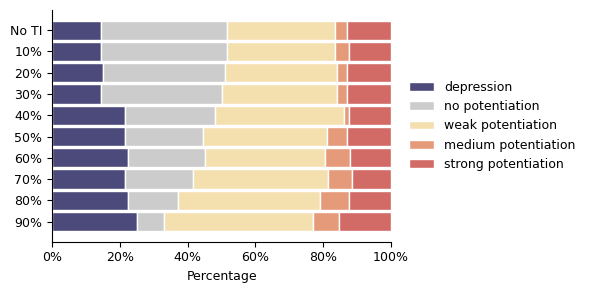

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

order = [
    "depression",
    "no potentiation",
    "weak potentiation",
    "medium potentiation",
    "strong potentiation"
]

palette = {
    "depression": "#4B4A7A",
    "no potentiation": "#CCCCCC",
    "weak potentiation": "#F4DFAF",
    "medium potentiation": "#E59B7A",
    "strong potentiation": "#D26B66"
}

def categorize(w):
    if w > 0.8:
        return "strong potentiation"
    elif 0.6 < w <= 0.8:
        return "medium potentiation"
    elif 0.1 < w <= 0.6:
        return "weak potentiation"
    elif w == 0.1:
        return "no potentiation"
    else:
        return "depression"

results["Group"] = pd.Categorical(
    results["Weights"].apply(categorize),
    categories=order,
    ordered=True
)

group_counts = (
    results
    .groupby(["Amplitude", "Group"], observed=True)
    .size()
    .reset_index(name="Count")
)

group_props = (
    group_counts
    .groupby("Amplitude", group_keys=False)
    .apply(lambda df: df.assign(Proportion=df["Count"] / df["Count"].sum()))
)

pivot = group_props.pivot(index="Amplitude", columns="Group", values="Proportion")
pivot = pivot[order].fillna(0)

# reorder rows: No TI, Pure carrier at top
priority = ["No TI"]
new_index = priority + [i for i in pivot.index if i not in priority]
pivot = pivot.loc[new_index]

fig, ax = plt.subplots(figsize=(6, 3))

y_pos = range(len(pivot.index))
left = [0] * len(pivot.index)

for group in order:
    values = pivot[group].values
    ax.barh(
        y_pos,
        values,
        left=left,
        color=palette[group],
        edgecolor="white",
        linewidth=1,
        height=0.9,
        label=group
    )
    left = [l + v for l, v in zip(left, values)]

ax.set_yticks(y_pos)
ax.set_yticklabels(pivot.index)

ax.set_xlabel("Percentage")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# invert so first rows appear at top
ax.invert_yaxis()

ax.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
def expand_time(original, max_time = 10_000, time_step = 0.025):
    original["Time"] = (original["Time"] / time_step).round() * time_step
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + time_step, time_step)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

In [13]:
import pandas as pd
from functools import reduce

dfs = []

amplitude = 0.6
stim = f"{carrier}_{beat}_{amplitude}"
filetype = "synapse_weights.csv"
# stim = "noTI"

for cell_id in cell_ids:
    filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/{filetype}"
    
    df = pd.read_csv(filename, index_col = 0)
    df = expand_time(df).set_index("Time")

    # make synapse columns unique per cell
    syn_cols = [c for c in df.columns if c != "Time"]
    df = df.rename(columns={c: f"{c}_cell{cell_id}" for c in syn_cols})

    dfs.append(df)

# merge all on Time
df = reduce(lambda left, right: pd.merge(left, right, on="Time", how="inner"), dfs)

In [14]:
def categorize(w):
    if w > 0.8:
        return "strong potentiation"
    elif w > 0.6:
        return "medium potentiation"
    elif w > 0.1:
        return "weak potentiation"
    elif w == 0.1:
        return "no potentiation"
    else:
        return "depression"

palette = {
    "depression": "#4B4A7A",
    "no potentiation": "#CCCCCC",
    "weak potentiation": "#F4DFAF",
    "medium potentiation": "#E59B7A",
    "strong potentiation": "#D26B66"
}

order = [
    "depression",
    "no potentiation",
    "weak potentiation",
    "medium potentiation",
    "strong potentiation"
]

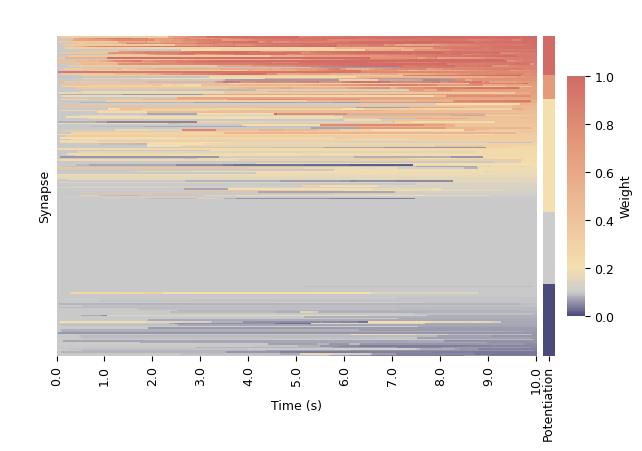

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# prepare dataframe
heatmap_df = df.T.copy()

# sort by final weight
final_weights = heatmap_df.iloc[:, -1]
heatmap_df = heatmap_df.loc[final_weights.sort_values(ascending=False).index]
final_weights = heatmap_df.iloc[:, -1]

# categories → row colors
categories = final_weights.apply(categorize)
categories.name = "Potentiation"
row_colors = categories.map(palette)

cmap = LinearSegmentedColormap.from_list(
    "custom_weights",
    [
        (0.0,  "#4B4A7A"),  # depression
        (0.1,  "#CCCCCC"),  # no potentiation
        (0.2, "#F4DFAF"),  # weak
        (0.7,  "#E59B7A"),  # medium
        (1.0,  "#D26B66")   # strong
    ]
)

# clustermap
g = sns.clustermap(
    heatmap_df,
    cmap = cmap,
    vmin = 0,
    vmax = 1,
    row_cluster = False,
    col_cluster = False,
    row_colors = row_colors,
    figsize = (6, 4),
    cbar_kws = {"label": "Weight"}
)

# move row colors to the RIGHT
g.ax_row_colors.set_position([0.91, 0.1, 0.02, 0.8])
g.ax_heatmap.set_position([0.1, 0.1, 0.8, 0.8])
g.cax.set_position([0.95, 0.2, 0.03, 0.6])

ax = g.ax_heatmap

# x ticks
time_values = heatmap_df.columns.values / 1000
ticks = np.linspace(0, len(time_values) - 1, 11).astype(int)
labels = np.round(np.linspace(time_values[0], time_values[-1], 11), 1)

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

# clean y axis
ax.set_yticks([])
ax.set_ylabel("Synapse")
ax.yaxis.set_label_position("left")

ax.set_xlabel("Time (s)")

plt.show()

## Example voltage traces and weight dynamics

In [16]:
cell_id = 10
frequency = 5
carrier = 1000
beat = 5
amplitudes = [-1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

filetype = "voltage.csv"

In [17]:
synapse_cols = [ f"Synapse{id}" for id in range(0, 10) ]

voltages = {}
mean_weights = {}
weights = {}
titles = {}
for amplitude in amplitudes:
  if amplitude == -1:
    stim = "noTI"
  else:
    if amplitude == 0: stim = f"{carrier}_0_0.32"
    else: stim = f"{carrier}_{beat}_{amplitude}"

  filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/voltage.csv"
  voltages[ stim ] = pd.read_csv(filename, index_col = 0)

  filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_weights.csv"
  synapse_weights = pd.read_csv(filename, index_col = 0)

  mean_weights[ stim ] = pd.DataFrame({
    "Time": synapse_weights.Time,
    "Weight": synapse_weights[synapse_cols].to_numpy().mean(axis = 1),
  })

  weights[ stim ] = synapse_weights

  if amplitude == -1:
    titles[ stim ] = "No TI"
  else:
    if amplitude == 0: titles[ stim ] = "Pure carrier"
    else: titles[ stim ] = f"{round(amplitude * 100)}%"

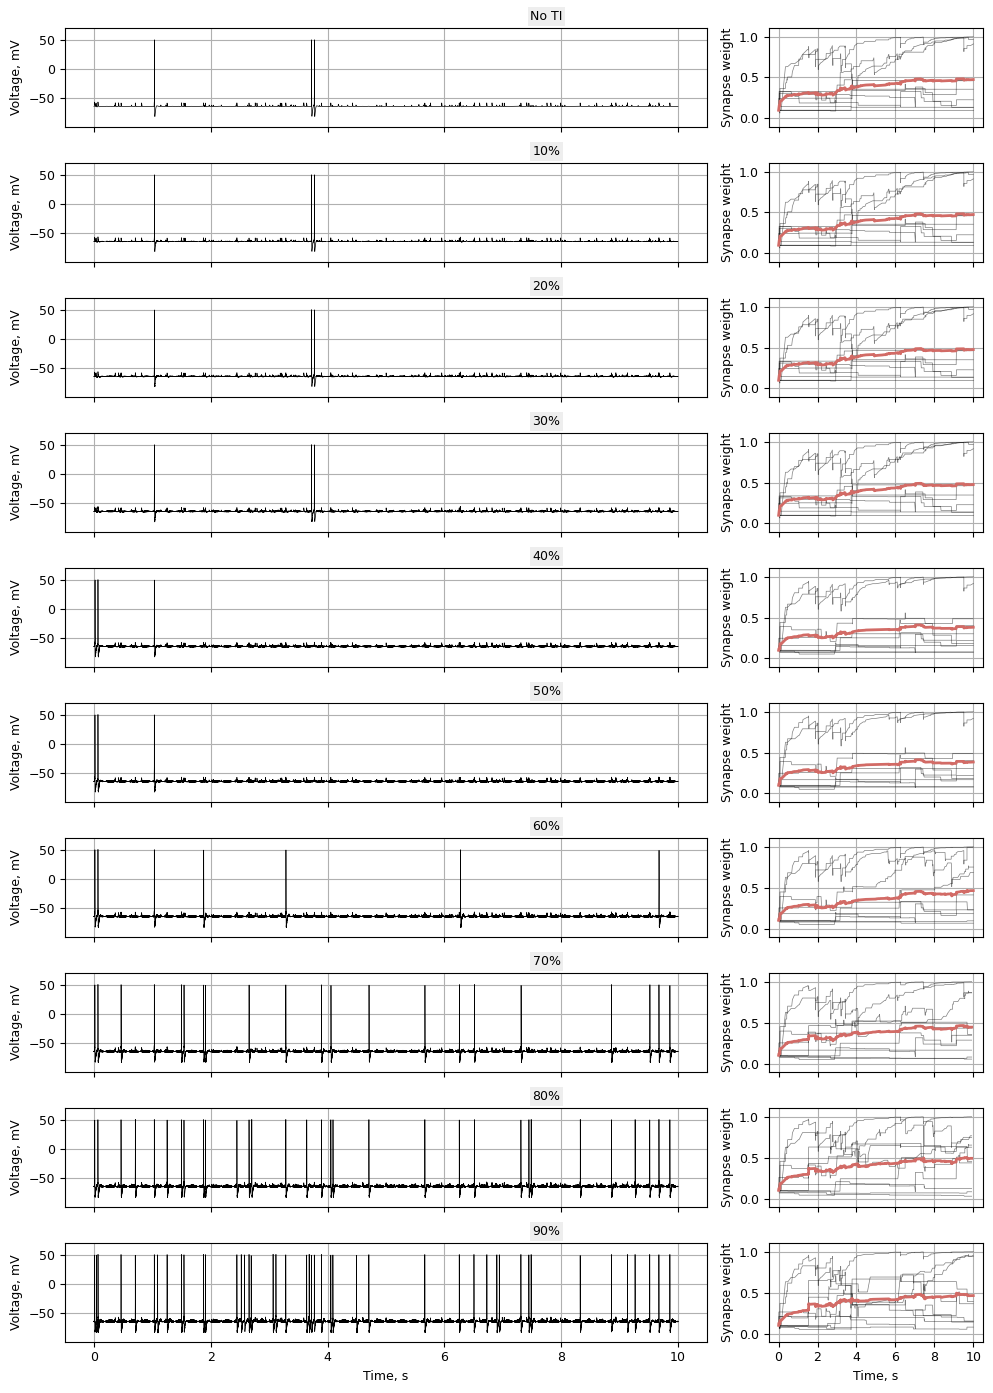

In [18]:
fig, axs = plt.subplots(nrows = len(voltages), ncols = 2, figsize = (10, len(voltages) * 1.4), sharex = True, gridspec_kw = {"width_ratios": [ 3, 1 ]})


for ax, stimulation in zip(axs[:, 0], voltages.keys()):
  voltage = voltages[stimulation]
  ax.plot(voltage.Time / 1000, voltage.Voltage, linewidth = 0.5, color = "black")
  ax.set_ylim(-100, 70)
  ax.set_yticks([-50, 0, 50])
  ax.grid(0.25)
  ax.set_ylabel("Voltage, mV")

  ax.title.set_bbox(dict(facecolor="#EEEEEE", edgecolor="none", pad=2))
  ax.title.set_position((0.75, 0))
  ax.set_title(titles[ stimulation ])

  if (stimulation == list(voltages.keys())[-1]):
    ax.set_xlabel("Time, s")

for ax, stimulation in zip(axs[:, 1], weights.keys()):
  synapse_weights = weights[ stimulation ]
  for synapse in synapse_cols:
    ax.plot(synapse_weights.Time / 1000, synapse_weights[synapse], linewidth = 0.5, alpha = 0.5, color = "black")

  weight = mean_weights[ stimulation ]
  ax.plot(weight.Time / 1000, weight.Weight, linewidth = 2, color = "#D26B66")
  ax.set_ylim(-0.1, 1.1)
  ax.grid(0.25)
  ax.set_ylabel("Synapse weight")

  if (stimulation == list(weights.keys())[-1]):
    ax.set_xlabel("Time, s")

plt.tight_layout()
plt.savefig(fname = "figure-results_example-traces-1000Hz+5Hz.png", dpi = 300)

## Average weight change

In [19]:
def expand_time(original, max_time = 10_000, time_step = 0.025):
  original["Time"] = (original["Time"] / time_step).round() * time_step
  original = original.sort_values("Time")

  new_time = np.arange(0, max_time + time_step, time_step)

  expanded = pd.DataFrame({ "Time": new_time })
  expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

  return expanded


cell_ids = np.arange(0, 20)
frequency = 5
carrier = 1000
beat = 5
amplitudes = [-1, 0.6, 0.9]

synapse_cols = [ f"Synapse{id}" for id in range(0, 10) ]

change_in_weights = {}
final_weights = {}
titles = {}
for amplitude in amplitudes:
  if amplitude == -1:
    stim = "noTI"
    titles[ stim ] = "No TI"
  else:
    if amplitude == 0:
      stim = f"{carrier}_0_0.32"
      titles[ stim ] = f"{carrier} Hz carrier"
    else:
      stim = f"{carrier}_{beat}_{amplitude}"
      titles[ stim ] = f"{round(amplitude * 100)}% tTIS"

  # Combine results from all cells
  weights = list()
  final = list()
  for cell_id in cell_ids:
    filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_weights.csv"
    synapse_weights = pd.read_csv(filename, index_col = 0)
    # Expand in time domain
    synapse_weights = expand_time(synapse_weights).set_index("Time")
    # Rename columns to include cell id
    synapse_weights.rename(columns = {old: f"{old}_{cell_id}" for old in synapse_cols}, inplace = True)
    weights.append(synapse_weights)
    final.append(synapse_weights.iloc[-1].tolist())
  
  # Merge results from all cells
  weights = reduce(lambda left, right: pd.merge(left, right, on = "Time", how = "inner"), weights)

  # Calculate weight change average
  change = weights.to_numpy() - 0.1
  change = np.abs(change)
  mean_change = change.mean(axis = 1)

  errors = change.std(axis = 1) / np.sqrt(change.shape[1])

  change_in_weights[ stim ] = pd.DataFrame({
    "Time": weights.index / 1000,
    "Change": mean_change,
    "Error": errors
  })

  final_weights[ stim ] = np.abs(np.array(final).flatten() - 0.1)

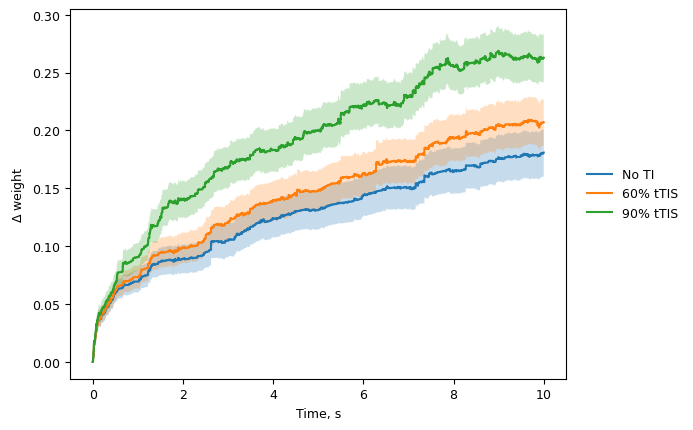

In [20]:
for stimulation in change_in_weights.keys():
  weights = change_in_weights[ stimulation ]
  plt.plot(weights.Time, weights.Change, label = titles[ stimulation ])

  plt.fill_between(
      weights.Time, weights.Change - weights.Error, weights.Change + weights.Error,
      alpha = 0.25,
      edgecolor = None
    )

plt.legend(
    bbox_to_anchor = (1.02, 0.5),
    loc = "center left",
    frameon = False
)

plt.xlabel("Time, s")
plt.ylabel(r"$\Delta$ weight")
plt.show()

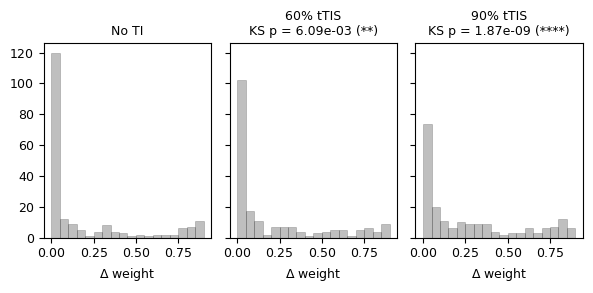

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# bins (global)
bin_width = 0.05
bins = np.arange(0, 0.9 + bin_width, bin_width)

# reference (No TI)
ref_key = "noTI"
ref_weights = final_weights[ref_key]

fig, axs = plt.subplots(
    nrows=1,
    ncols=len(final_weights),
    figsize=(len(final_weights) * 2, 3),
    sharey=True
)

for ax, stimulation in zip(axs, final_weights.keys()):
    weights = final_weights[stimulation]

    ax.hist(
        weights,
        edgecolor="black",
        facecolor="black",
        alpha=0.25,
        bins=bins,
        linewidth=0.5
    )

    ax.set_xlabel(r"$\Delta$ weight", fontsize=9)

    if stimulation == ref_key:
        ax.set_title(titles[stimulation], fontsize=9)
    else:
        ks_stat, p_val = ks_2samp(ref_weights, weights)
        stars = p_to_stars(p_val)
        ax.set_title(
            f"{titles[stimulation]}\nKS p = {p_val:.2e} ({stars})",
            fontsize=9
        )

plt.tight_layout()
plt.show()

## Taking another look at the dendrites: are there really no effects?

In [22]:
cell_id = 0
amplitudes = [-1, 0.1, 0.2, 0.3, 0.4]
carrier = 1000
beat = 5
frequency = 5

threshold = 20

spike_counts = {}
dendritic_voltage = {}
for amplitude in amplitudes:
  if amplitude == -1:
    stim = "noTI"
  else:
    if amplitude == 0: stim = f"{carrier}_0_0.32"
    else: stim = f"{carrier}_{beat}_{amplitude}"
  
  filename_dendrite = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_voltage.csv"
  synapse_voltage = pd.read_csv(filename_dendrite, index_col = 0)

  dendritic_voltage[ stim ] = synapse_voltage

  syn_v = synapse_voltage[ synapse_cols ].to_numpy()
  spike_count = []
  for v in syn_v.T:
    spike_idx = np.where((v[:-1] >= threshold) & (v[1:] < threshold))[0]
    spike_count.append(len(spike_idx))
  
  spike_counts[ stim ] = spike_count

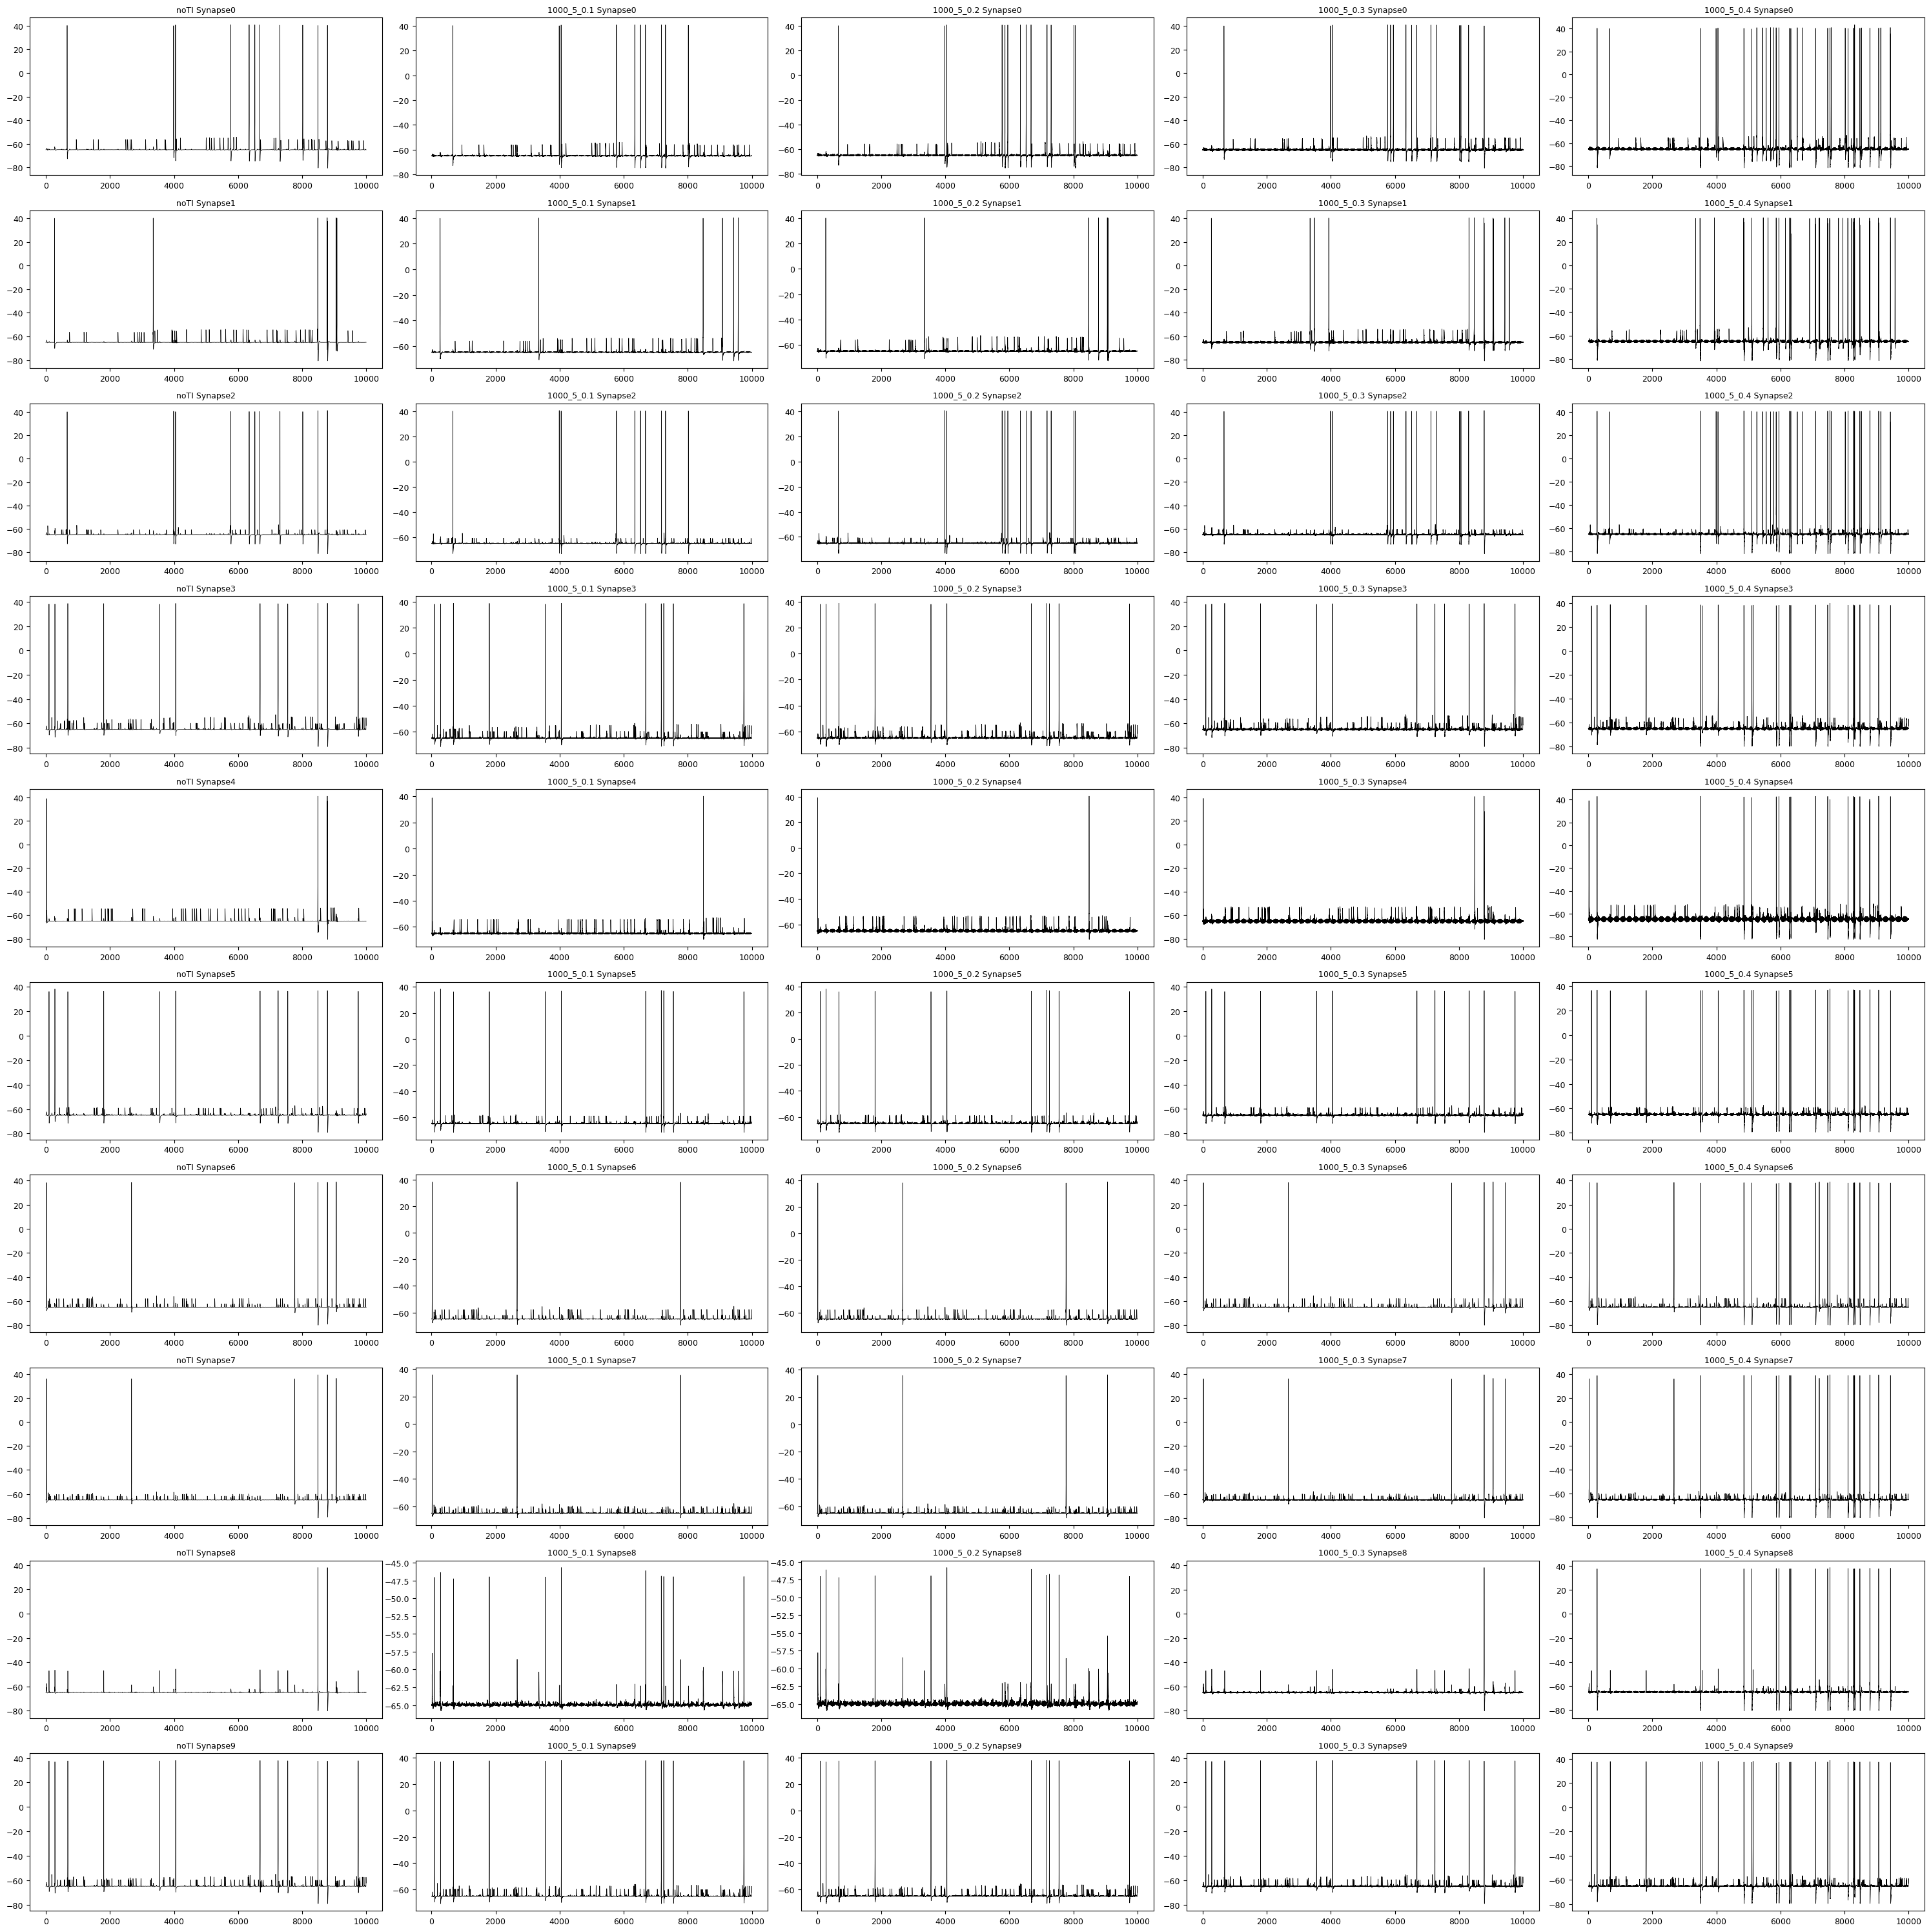

In [23]:
synapse_cols = [ f"Synapse{id}" for id in range(0, 10)  ]

fig, axs = plt.subplots(nrows = len(synapse_cols), ncols = len(dendritic_voltage), figsize = (len(dendritic_voltage) * 6, 3 * len(synapse_cols)))

for row, stimulation in enumerate(dendritic_voltage.keys()):
  voltage = dendritic_voltage[ stimulation ]
  for col, synapse in enumerate(synapse_cols):
    ax = axs[ col, row ]
    ax.plot(voltage.Time, voltage[ synapse ], color = "black", linewidth = 0.5)
    ax.set_title(f"{stimulation} {synapse}")

plt.tight_layout()
plt.show()

In [24]:
spike_counts

{'noTI': [11, 8, 11, 12, 5, 12, 6, 6, 2, 12],
 '1000_5_0.1': [10, 6, 10, 11, 2, 11, 3, 3, 0, 11],
 '1000_5_0.2': [13, 6, 13, 11, 2, 11, 4, 4, 0, 11],
 '1000_5_0.3': [15, 12, 15, 12, 4, 12, 6, 6, 1, 12],
 '1000_5_0.4': [34, 46, 33, 24, 20, 24, 21, 21, 18, 24]}

In [25]:
cell_ids = np.arange(0, 20)
amplitudes = [-1, 0, 0.1, 0.2, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
carrier = 1000
beat = 5
frequency = 5
threshold = 20

spike_counts = {}
titles = {}

for amplitude in amplitudes:
    if amplitude == -1:
      stim = "noTI"
      titles[ stim ] = "No TI"
    else:
      if amplitude == 0:
        stim = f"{carrier}_0_0.32"
        titles[ stim ] = "Pure\ncarrier"
      else:
        stim = f"{carrier}_{beat}_{amplitude}"
        titles[ stim ] = f"{round(amplitude * 100)}%"

    title = titles[ stim ]
    spike_counts[title] = []

    for cell_id in cell_ids:
      filename = f"../output/temporal-interference-1/{cell_id}/random_poisson/{frequency}/{stim}_0.1/synapse_voltage.csv"
      synapse_voltage = pd.read_csv(filename, index_col=0)

      syn_v = synapse_voltage[synapse_cols].to_numpy()

      spikes = (syn_v[:-1, :] >= threshold) & (syn_v[1:, :] < threshold)
      counts = np.sum(spikes, axis=0)

      spike_counts[title].extend(counts.tolist())

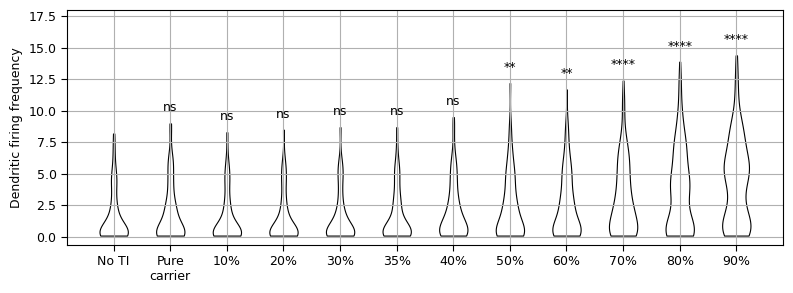

In [26]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def p_to_stars(p):
    if p < 1e-4:
        return "****"
    elif p < 1e-3:
        return "***"
    elif p < 1e-2:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

fig, ax = plt.subplots(figsize=(8, 3))

# convert to long format
data = []
for stim, counts in spike_counts.items():
  for c in counts:
    if c == 0: continue
    data.append({"Stimulation": stim, "SpikeCount": c / 10})

df = pd.DataFrame(data)

# group data
grouped = list(df.groupby("Stimulation"))
labels = [name for name, _ in grouped]
groups = [g["SpikeCount"].values for _, g in grouped]

# reorder
priority = ["No TI", "Pure\ncarrier"]
order = priority + [l for l in labels if l not in priority]

label_to_group = dict(zip(labels, groups))
labels = order
groups = [label_to_group[l] for l in labels]

# violin plot
vp = ax.violinplot(
    groups,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# style violins (black & white)
for body in vp["bodies"]:
    body.set_facecolor("white")
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(1)

# ticks
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)

ax.set_ylabel("Dendritic firing frequency")
ax.set_xlabel("")

ax.xaxis.set_ticks_position("bottom")
ax.yaxis.set_ticks_position("left")
ax.tick_params(axis="x", bottom=True, top=False, length=4)
ax.tick_params(axis="y", left=True, right=False, length=4)

# stats vs "No TI"
ref_idx = labels.index("No TI")

y_max = max([g.max() for g in groups])
y_offset = 0.05 * y_max

for i in range(len(groups)):
    if i == ref_idx:
        continue

    stat, p_val = stats.ttest_ind(groups[ref_idx], groups[i])
    stars = p_to_stars(p_val)

    x = i + 1
    y = groups[i].max() + y_offset

    ax.text(x, y, stars, ha="center", va="bottom")

ax.set_ylim(top=y_max + 5 * y_offset)

for spine in ["bottom", "left"]:
    ax.spines[spine].set_visible(True)

ax.grid(0.25)
plt.tight_layout()
plt.show()

In [27]:
strengths = pd.read_csv(f"../output/temporal-interference-1/variable-time-ef-intermediate/90_90_{carrier}_{beat}.csv")
stim_amplitude = strengths.SubthresholdAmplitude.values[0]

pd.DataFrame({
  "V/m": np.round(np.arange(0.1, 1.1, 0.1) * stim_amplitude),
  "%": np.round(np.arange(0.1, 1.1, 0.1) * 100)
})

,V/m,%
0,15.0,10.0
1,30.0,20.0
2,45.0,30.0
3,60.0,40.0
4,74.0,50.0
5,89.0,60.0
6,104.0,70.0
7,119.0,80.0
8,134.0,90.0
9,149.0,100.0


In [28]:
pure_carrier_amplitude = pd.read_csv(f"../output/temporal-interference-1/variable-time-ef-intermediate/90_90_{carrier}_0.csv").SubthresholdAmplitude.values[0]
print(round(stim_amplitude / pure_carrier_amplitude, 2))
pure_carrier_amplitude * 0.29 # TODO: update pure carrier with this value!

# TODO: pure carrier amplitude was set to 29% of its subthreshold strength which corresponded to the amplitude equivalent to the subthreshold amplitude of 1000 Hz carrier with 5 Hz beat frequency.

0.29


148.61083984375